# Seaborn

1. Seaborn은 Matplotlib 기반의 고수준 시각화 라이브러리이다.
2. Pandas DataFrame과 함께 쓰기 편하다.
3. 통계적 시각화를 더 적은 코드로 그릴 수 있다.

## ⚙️환경설정

In [1]:
#!conda install seaborn -y

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Mac 기준 한글 폰트 설정
plt.rcParams["font.family"] = "AppleGothic"
# 마이너스 부호 깨짐 문제 방지
plt.rcParams["axes.unicode_minus"] = False

In [3]:
sns.__version__

'0.13.2'

## 1. Seaborn 첫 인상: pairplot
여러 수치형 변수의 관계를 한 번에 보고 싶을 때 pairplot이 유용하다. 단, 변수 수가 많으면 그래프가 무거워질 수 있다.

In [4]:
# Seaborn의 기본 테마 설정 (그래프 스타일을 깔끔하게 'ticks' 스타일로 지정)
sns.set_theme(style="ticks")

# Seaborn 내장 데이터셋인 'penguins'(펭귄 데이터) 불러오기
# 데이터 구성: 종(species), 섬(island), 부리 길이/깊이, 몸무게, 성별 등
df = sns.load_dataset("penguins")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


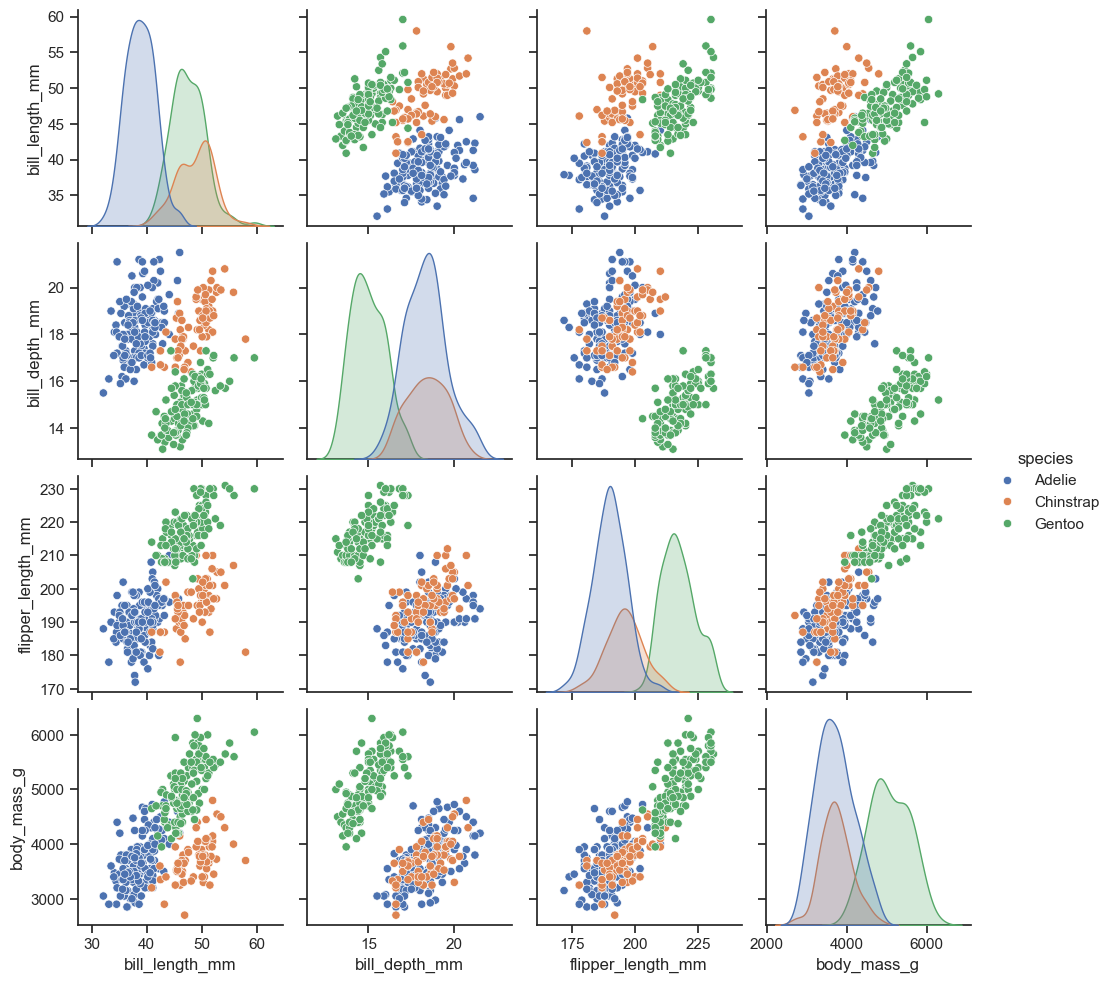

In [5]:
# pairplot 생성
# hue="species": '종(species)' 컬럼에 따라 점의 색상을 다르게 표시 (범주형 구분)
# diag_kind="kde": (선택사항) 대각선에 히스토그램 대신 부드러운 밀도 곡선을 그릴 수도 있음
sns.pairplot(df, hue="species") 

# 그래프 출력
plt.show()

## 2. Histogram 계열
연속형 데이터의 구간별 도수분포 시각화
1. displot(): Figure-level 함수 (figsize 직접 설정)
2. histplot(): Axes-level 함수 (figure 설정은 matplotlib 통해 처리)

In [6]:
# 타이타닉데이터 로드
titanic_df = pd.read_csv('data/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


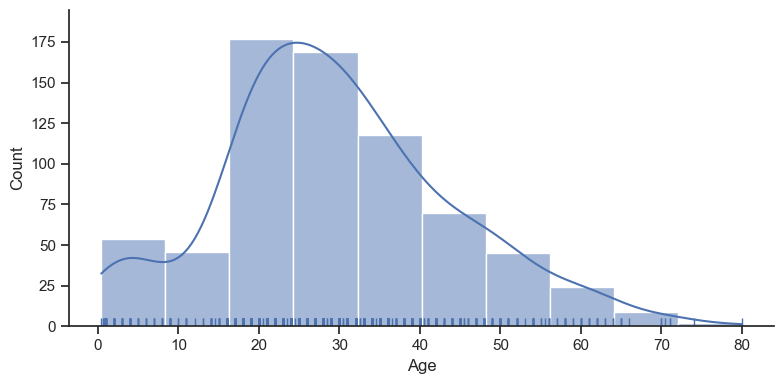

In [7]:
# figure레벨 함수: 전체적인 도화지의 크기와 비율을 매개변수로 조절
# - height: 그래프 한 칸의 높이 (인치 단위)
# - aspect: 높이 대비 너비의 비율 (너비 = height * aspect)
# - kde (Kernel Density Estimation): 데이터의 분포를 부드러운 곡선으로 나타낸 밀도 추정 그래프
# - rug: x축 위에 데이터의 실제 위치를 작은 선(태슬)으로 표시

sns.displot(
    titanic_df['Age'], 
    bins=10,        # 데이터를 나눌 구간의 개수
    height=4,       # 그래프의 세로 길이를 4인치로 설정
    aspect=2,       # 가로 길이를 세로의 2배(8인치)로 설정 (8 x 4 크기의 그래프)
    rug=True,       # 개별 데이터의 위치를 바닥에 선으로 표시
    kde=True        # 막대 그래프 위에 부드러운 밀도 곡선 추가
)

plt.show()

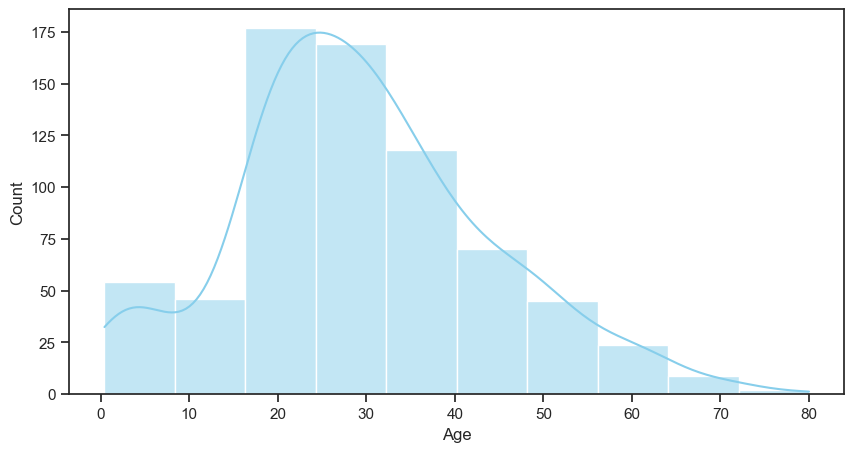

In [8]:
# 1. Matplotlib을 사용하여 전체 도화지(Figure) 크기를 먼저 설정
# figsize=(가로, 세로) 단위는 인치(Inch)
plt.figure(figsize=(10, 5)) 

# 2. Axes-level 함수인 histplot을 호출
# 별도의 크기 조절 인자(height, aspect) 없이, 위에서 만든 10x5 크기의 도화지에 꽉 차게 그려지도록 설정
sns.histplot(
    titanic_df['Age'], 
    bins=10,        # 데이터를 10개의 구간으로 나눔
    kde=True,       # 밀도 추정 곡선(Kernel Density Estimation) 표시
    color='skyblue' # (선택사항) 막대의 색상 지정
)

# 3. 그래프 출력
plt.show()

Text(0.5, 1.0, '타이타닉 승객 나이 분포(20개 구간)')

/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 45769 (\N{HANGUL SYLLABLE NIG}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 49849 (\N{HANGUL SYLLABLE SEUNG}) missing from font(s) Arial.
  func(*args, **kwargs)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) Arial.

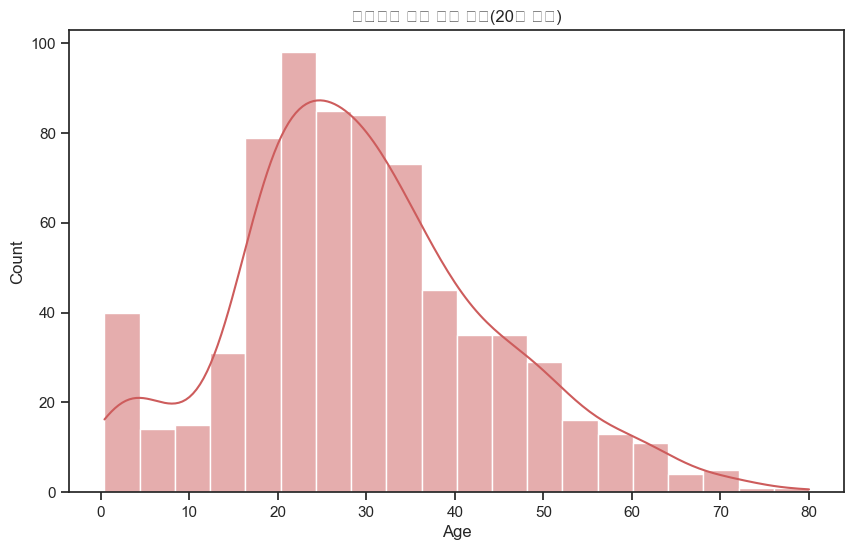

In [9]:
# TODO - Histogram
# titanic_df의 Age 분포를 histplot으로 다시 그려보세요.
# 조건 
# 1) bins를 조절하기 
# 2) kde=True로 밀도곡선 추가하기 
# 3) 제목을 직접 설정하기
plt.figure(figsize=(10, 6))
sns.histplot(titanic_df['Age'], bins=20, kde=True, color='indianred')
plt.title("타이타닉 승객 나이 분포(20개 구간)")

## 3. Count Plot / Bar Plot
범주형 데이터의 개수와, 범주별 수치형 데이터의 대표값을 구분해서 시각화한다.
- 개수: countplot()
- 수치값: barplot()

/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/p

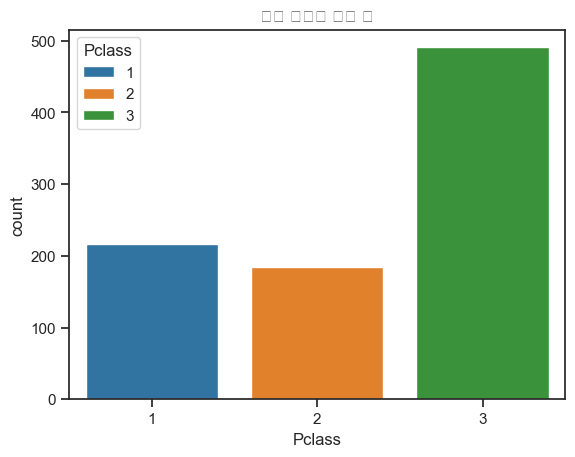

In [10]:
# countplot: 범주형 변수의 빈도수를 막대그래프로 나타냄
# - x='Pclass': 선실 등급별로 그룹을 나눔
# - palette='tab10': 미리 정의된 색상 팔레트를 적용
# - hue='Pclass': 등급별로 색상을 다르게 지정 (최신 Seaborn에서는 x와 동일하게 지정 권장).

sns.countplot(x='Pclass', data=titanic_df, palette='tab10', hue='Pclass')
plt.title('선실 등급별 승객 수')
plt.show()

/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 46321 (\N{HANGUL SYLLABLE DEUNG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yjson616/miniforge3/envs/ai_basic_env/lib/python3.12/site-packages/IPython/core/p

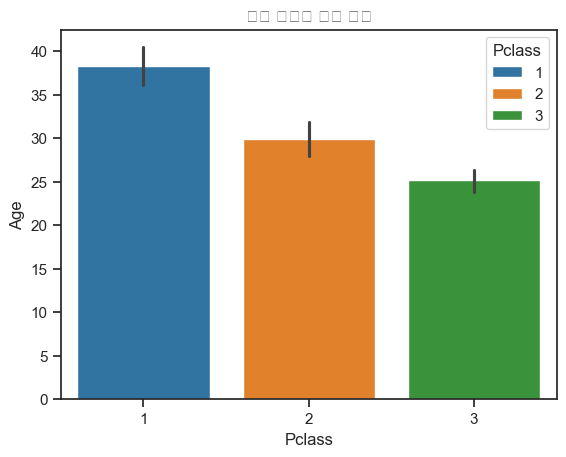

In [11]:
# barplot: 범주형(x) 대비 수치형(y)의 통계치(평균 등)를 시각화
# - estimator=np.mean: 막대의 높이를 무엇으로 결정할지 지정 (평균, 합계, 중앙값 등).
# - errorbar=('ci', 95): 막대 끝에 표시된 검은색 선(에러바)으로, 95% 신뢰구간을 의미
#   (데이터가 얼마나 퍼져있는지, 평균값이 얼마나 믿을만한지)

sns.barplot(
    data=titanic_df, 
    x='Pclass', 
    y='Age',
    hue='Pclass', 
    palette='tab10',
    estimator=np.mean,       # 평균값으로 막대 높이 설정
    errorbar=('ci', 95)      # 95% 신뢰구간 표시 (기본값) -> 없애려면 None
)
plt.title('선실 등급별 평균 나이')
plt.show()

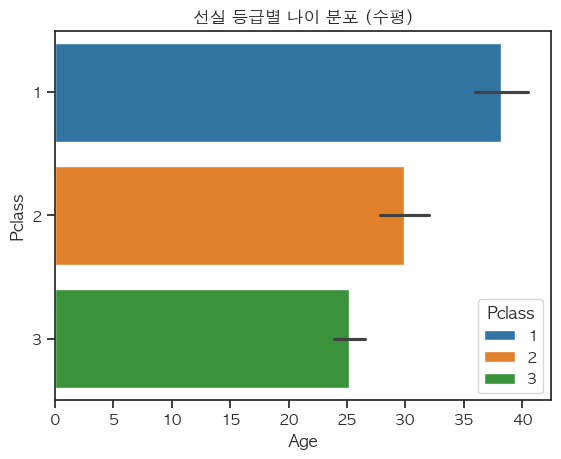

In [40]:
# 수평 막대 그래프 (Horizontal Bar Plot)
# - orient='h': 그래프를 가로 방향으로 그림
# - 주의: 수평 방향일 때는 x축에 수치(Age), y축에 범주(Pclass)를 넣어야 함

sns.barplot(
    data=titanic_df, 
    x='Age', 
    y='Pclass', # 범주형 데이터가 y축으로!
    hue='Pclass', 
    palette='tab10',
    orient='h'   # 수평 방향 설정
)
plt.title('선실 등급별 나이 분포 (수평)')
plt.show()

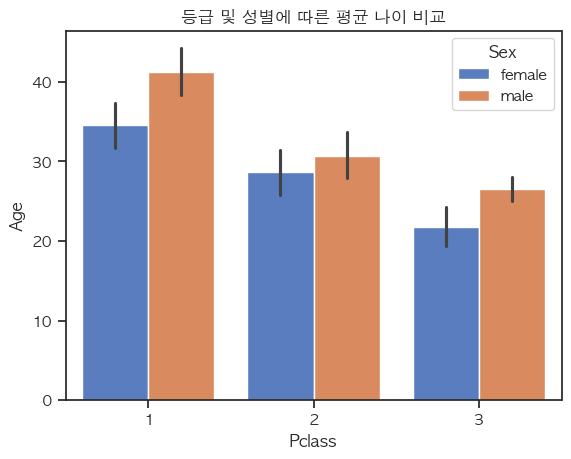

In [41]:
# 다중 그룹화 (Multiple Grouping)
# - x축은 선실 등급(Pclass)으로 나누고, 그 안에서 다시 성별(Sex)로 색상을 나누어 비교
# - 등급별/성별별 평균 나이 차이를 한눈에 볼 수 있음

sns.barplot(
    data=titanic_df, 
    x='Pclass', 
    y='Age',
    hue='Sex',    # 성별에 따라 막대를 쪼개서 표시
    palette='muted'
)
plt.title('등급 및 성별에 따른 평균 나이 비교')
plt.show()

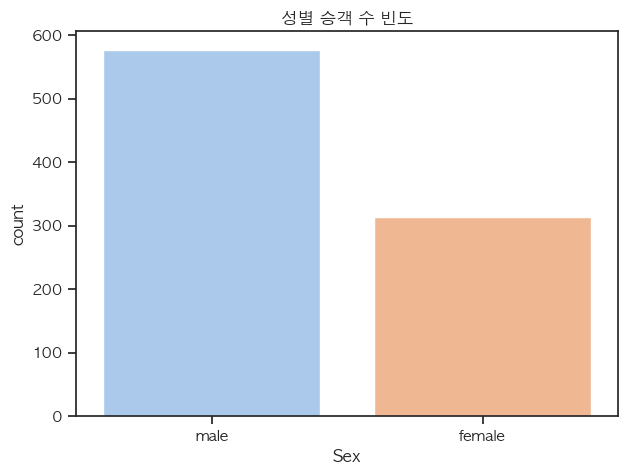

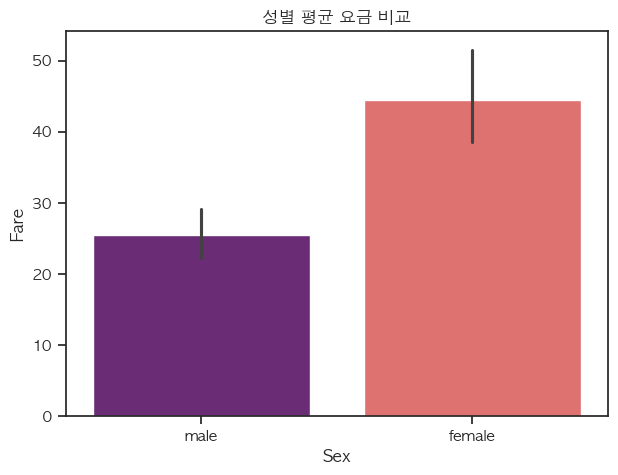

In [42]:
# TODO - Count / Bar Plot
# 1) countplot으로 Sex 분포를 그려보기
# 2) barplot으로 Sex별 평균 Fare를 그려보기
# 3) 어떤 그래프가 '개수', 어떤 그래프가 '평균'을 보여주는지 markdown 셀에 적기

plt.figure(figsize=(7, 5))
sns.countplot(data=titanic_df, x="Sex", palette="pastel", hue="Sex")
plt.title("성별 승객 수 빈도")
plt.show()

plt.figure(figsize=(7, 5))
sns.barplot(data=titanic_df, x="Sex", y="Fare", palette="magma", hue="Sex")
plt.title("성별 평균 요금 비교")
plt.show()

## 4. Box Plot / Violin Plot
둘 다 분포를 보지만, Violin Plot은 밀도 모양까지 함께 보여준다는 점이 핵심이다.

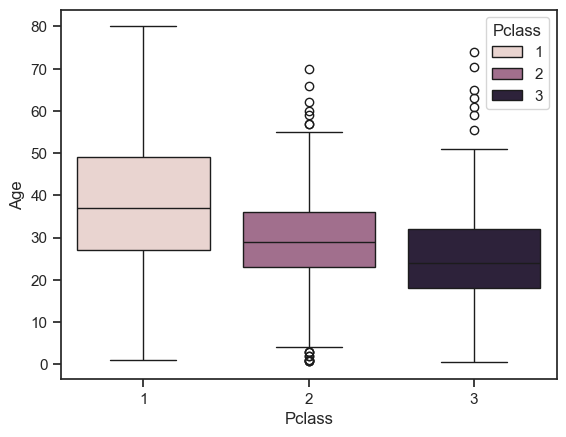

In [15]:
# boxplot
sns.boxplot(data=titanic_df, x='Pclass', y='Age', hue='Pclass')
plt.show()

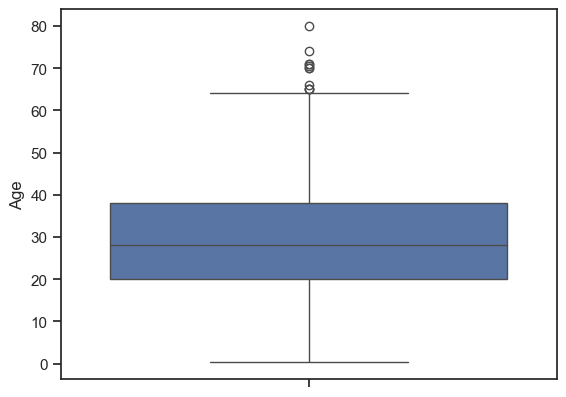

In [16]:
# 나이 시각화
sns.boxplot(data=titanic_df, y='Age')
plt.show()

### Violin Plot
데이터 분포와 kde(연속확률분포곡선)을 통해 도수분포도 함께 시각화

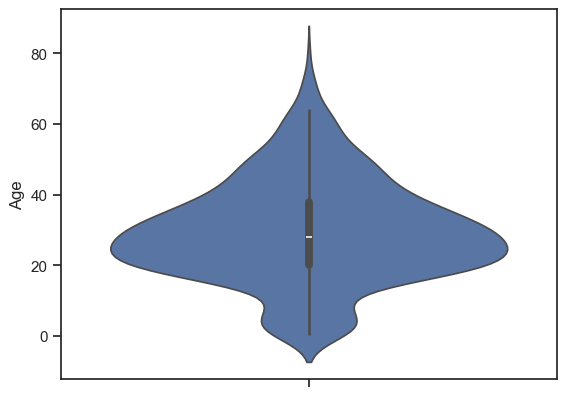

In [17]:
# 나이 시각화
sns.violinplot(data=titanic_df, y='Age')
plt.show()

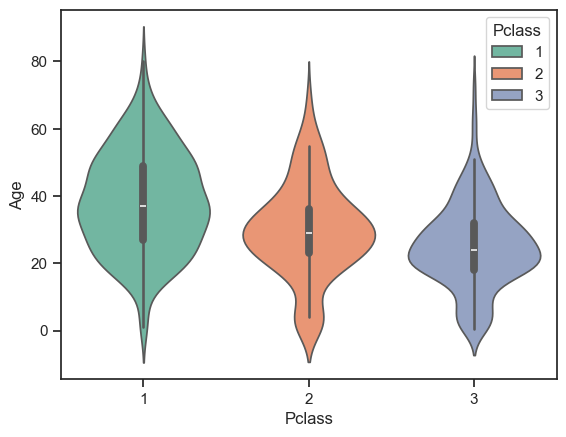

In [18]:
# 선실등급별 나이평균 시각화
sns.violinplot(data=titanic_df, x='Pclass', y='Age', hue='Pclass', palette='Set2')
plt.show()

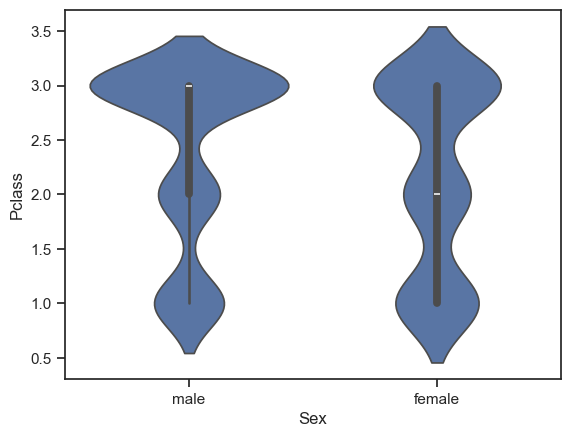

In [19]:
# y축에 범주값을 작성하는 경우
sns.violinplot(data=titanic_df, x='Sex', y='Pclass')
plt.show()

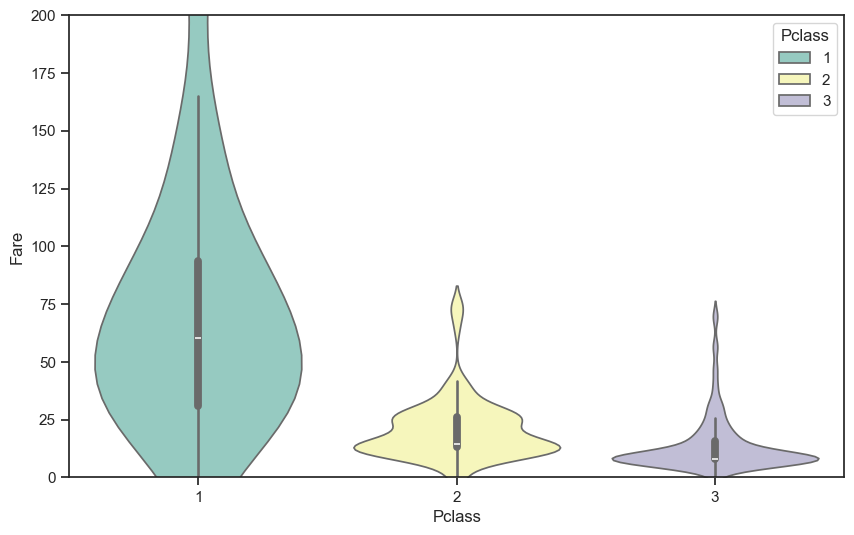

In [20]:
# TODO - Box / Violin Plot
# titanic_df에서 Pclass별 Fare 분포를 boxplot 또는 violinplot으로 그려보세요.
# 조건
# 1) x축은 Pclass, y축은 Fare
# 2) hue를 추가할지 스스로 선택하기
# 3) 어떤 차트가 더 해석하기 쉬운지 
plt.figure(figsize=(10, 6))
# sns.boxplot(data=titanic_df, x="Pclass", y="Fare", hue="Pclass", palette="Set3")
sns.violinplot(data=titanic_df, x="Pclass", y="Fare", hue="Pclass", palette="Set3")
plt.ylim(0, 200)
plt.show()

## 5. Scatter Plot
- 두개의 연속형데이터에 대해 데이터분포를 시각화
- Seaborn은 hue, style, size 같은 옵션을 붙여서 산점도를 더 풍부하게 표현하기 좋다.

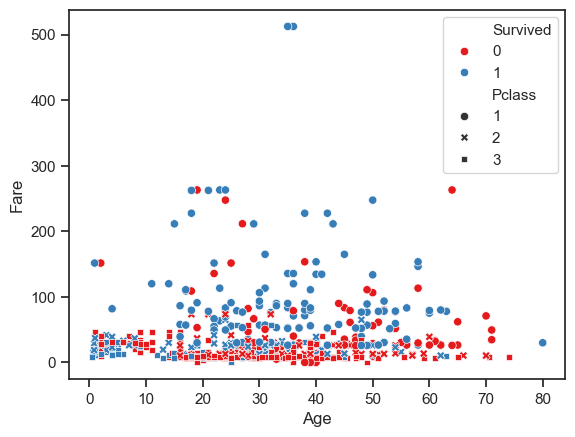

In [21]:
sns.scatterplot(data=titanic_df, x='Age', y='Fare',
                hue='Survived', palette='Set1',
                style='Pclass')
plt.show()

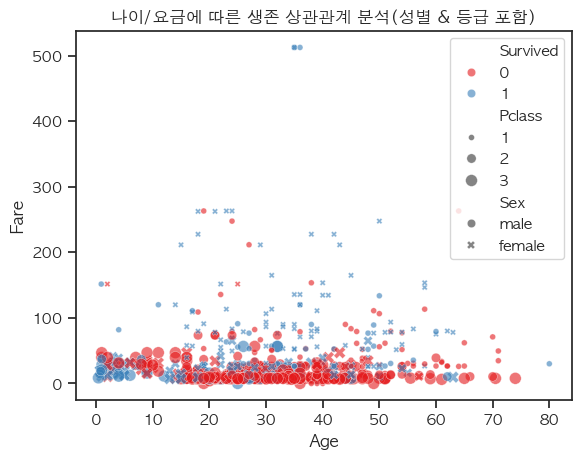

In [43]:
# TODO - Scatter Plot
# titanic_df를 이용해 Age와 Fare 산점도를 그려보며 데이터의 밀집도와 다차원 관계를 분석
# 조건
# 1) x축은 Age, y축은 Fare로 설정하기
# 2) hue(색상)는 Survived로 설정하여 생존 여부 확인하기
# 3) style(모양)은 Sex를 적용해 성별 차이 보기
# 4) size(크기)는 Pclass를 적용해 선실 등급의 영향력 시각화하기 (점 크기가 등급을 의미)
# 5) alpha(투명도)를 조절하여 데이터가 겹친 구간(밀집도) 확인하기
# 6) 그래프 제목(Title) 추가하기
sns.scatterplot(data=titanic_df, x='Age', y='Fare',
                hue='Survived', palette="Set1",
                style='Sex', size='Pclass', alpha=0.6)
plt.title("나이/요금에 따른 생존 상관관계 분석(성별 & 등급 포함)")
plt.show()

## 6. Heatmap
- 컬럼간의 상관도를 시각화
- 상관계수 행렬을 색으로 표현해 변수 간 관계를 빠르게 파악한다. 상관계수는 -1 ~ 1 범위이다.

### 상관계수 (Correlation Coefficient)란?

> 두 변수 간에 **서로 얼마나 함께 움직이는지**를 나타내는 수치.

- **양의 상관**: 같이 커지고 같이 작아짐 → 상관계수 > 0
- **음의 상관**: 한쪽이 커질 때 다른쪽이 작아짐 → 상관계수 < 0
- **상관 없음**: 서로 관계가 없음 → 상관계수 ≈ 0

**상관계수 값 해석**

| 상관계수 값 | 의미 |
|:---|:---|
| +1 | 완벽한 양의 상관 |
| 0 | 상관 없음 |
| -1 | 완벽한 음의 상관 |


**피어슨 상관계수 공식**

피어슨 상관계수 $ r $ 공식:

$$
r = \frac{공분산(X, Y)}{표준편차(X) \times 표준편차(Y)}
$$

- **공분산**: 두 변수가 함께 변하는 정도. 값이 들쑥날쑥이라 상관계수로 표현하기 어려움
- **표준편차**: 각각 변수가 얼마나 퍼져 있는지


#### 공분산이란?
> 두 변수가 얼마나 함께 변하는지를 측정하는 값.

$$
공분산(X, Y) = \frac{\sum (X_i - 평균(X))(Y_i - 평균(Y))}{n}
$$

- 양수 → 같은 방향으로 움직임
- 음수 → 반대 방향으로 움직임
- 0 → 관련 없음

**피어슨 상관계수 계산 흐름**

1. **평균** 계산 (X와 Y 각각)
2. **편차** 계산 (각 데이터 - 평균)
3. **편차끼리 곱해서 평균** → 공분산 계산
4. **각 변수의 표준편차** 계산
5. **공분산 ÷ (표준편차 X × 표준편차 Y)** → 피어슨 상관계수 완성

In [44]:
# 상관계수(-1 ~ 1) 도출
# - 1에 가까우면 양의 상관관계
# - 0에 가까우면 관계에 없다.
# - -1에 가까우면 음의 상관관계
corr_mat = titanic_df.corr(numeric_only=True) # 수치형데이터만 상관계수 계산이 가능
corr_mat

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


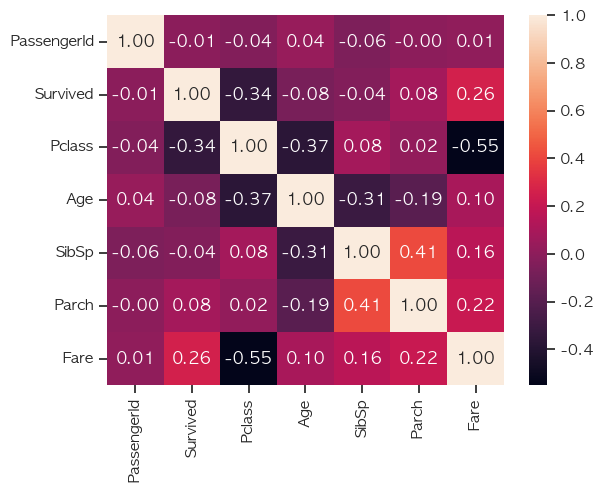

In [45]:
# 히트맵 시각화
# - corr_mat: 상관계수 행렬 데이터
# - annot=True: 각 칸에 상관계수 숫자를 직접 표시함
# - fmt='.2f': 숫자를 표시할 때 '소수점 둘째 자리'까지 보여주라는 형식(format) 지정

sns.heatmap(corr_mat, annot=True, fmt='.2f')
plt.show()

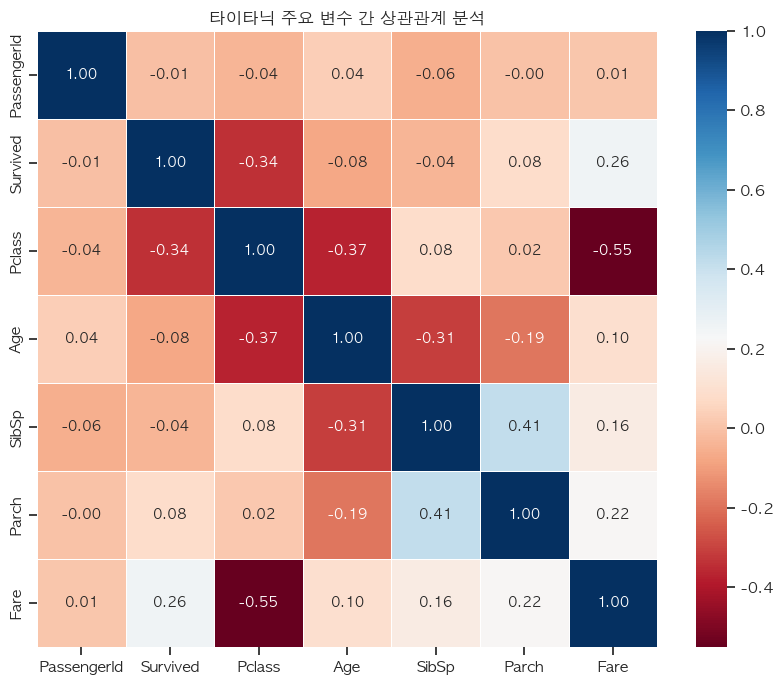

In [47]:
# TODO - Heatmap
# 상관계수 행렬을 시각화하여 변수 간의 숨겨진 연결고리를 찾기
# 조건
# 1) 상관계수 숫자를 표시하되(annot=True), 글자 크기를 10으로 설정 (annot_kws={'size': 10})
# 2) 각 칸 사이의 경계선을 그려 가독성을 높이기 (linewidths=0.5)
# 3) 컬러맵(cmap)은 'RdBu' 또는 'PiYG' 등 양극단이 대비되는 팔레트를 사용
# 4) 상관계수 결과에서 '생존(Survived)'과 가장 관련이 깊어 보이는 변수(절댓값이 큰 것)가 무엇인지 찾기
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_mat,
    annot=True,
    annot_kws={'size': 10},
    linewidths=0.5,
    cmap='RdBu',
    fmt=".2f"
)
plt.title("타이타닉 주요 변수 간 상관관계 분석")
plt.show()

## 7. Pairplot
여러 변수 간의 관계를 한꺼번에 볼 수 있어 탐색적 데이터 분석(EDA)에서 자주 사용한다.

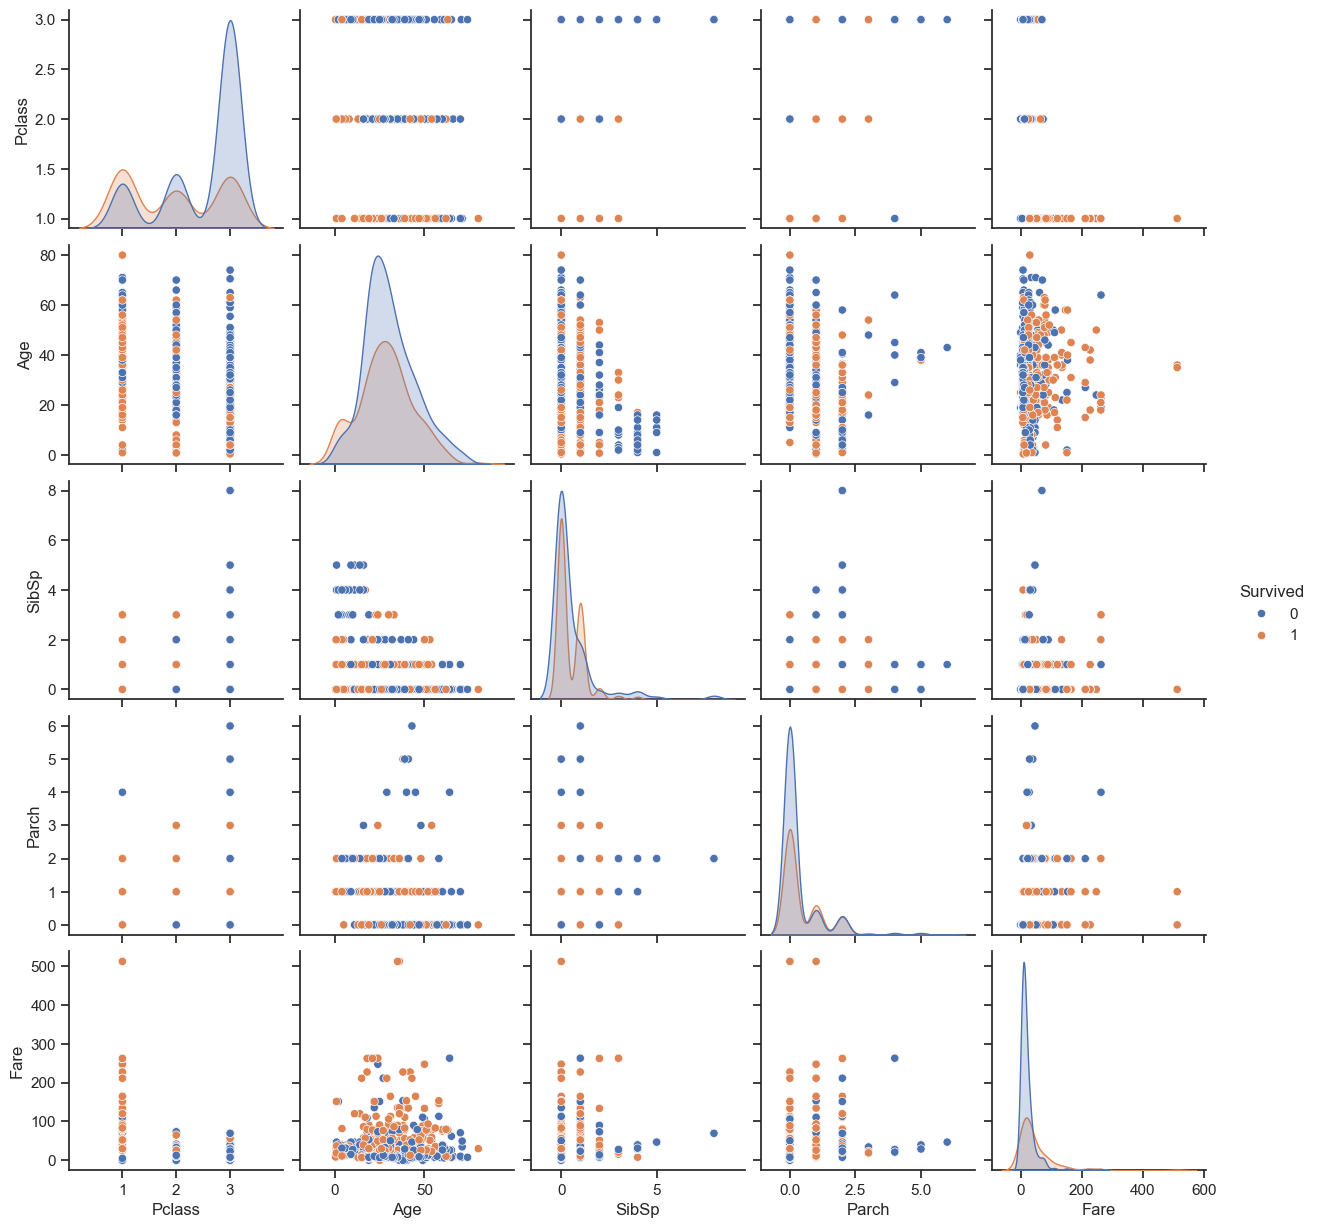

In [26]:
sns.pairplot(titanic_df[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Survived']], hue='Survived')
plt.show()

In [27]:
# seaborn 제공하는 dataset
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [28]:
tips_df = sns.load_dataset("tips")
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


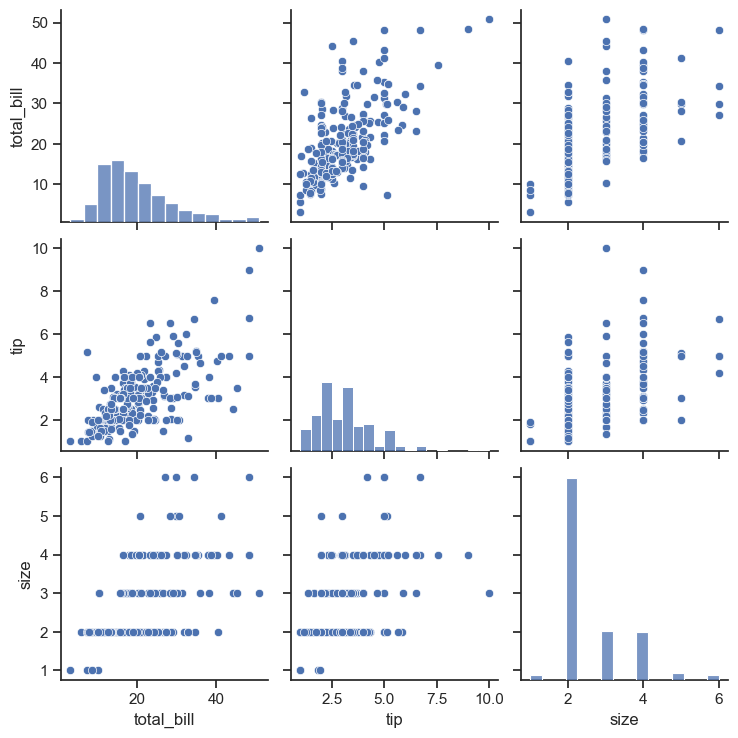

In [29]:
sns.pairplot(tips_df)
plt.show()

In [ ]:
# TODO - Pairplot 
# tips_df를 활용해 흡연 여부나 시간대에 따른 팁 패턴을 분석

# 조건
# 1) 'total_bill', 'tip', 'size' 수치형 컬럼과 범주형 컬럼 'smoker'를 함께 선택하기
# 2) hue='smoker'를 적용해 흡연자와 비흡연자의 분포 차이 시각화하기
# 3) palette='husl' 또는 'Set2'를 사용하여 색상을 산뜻하게 바꾸기

sns.pairplot(tips_df[['total_bill', 'tip', 'size', 'smoker']])


## 8. Regplot
- X축, Y축의 데이터에 대한 산포도와 회귀선(선형/비선형)을 추가해 시각화
- 산점도 위에 회귀선을 함께 그려 두 변수의 선형 관계를 빠르게 볼 수 있다.

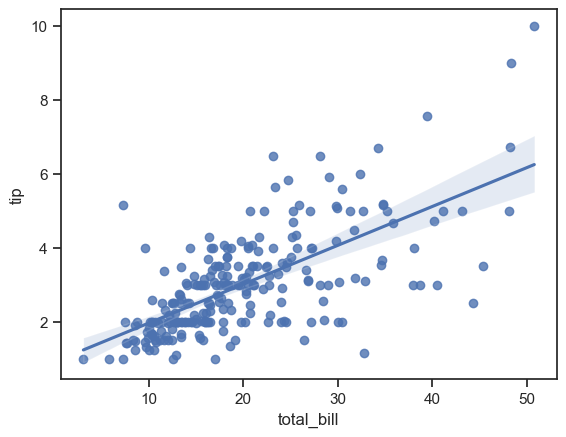

In [31]:
sns.regplot(data=tips_df, x='total_bill', y='tip')
plt.show()

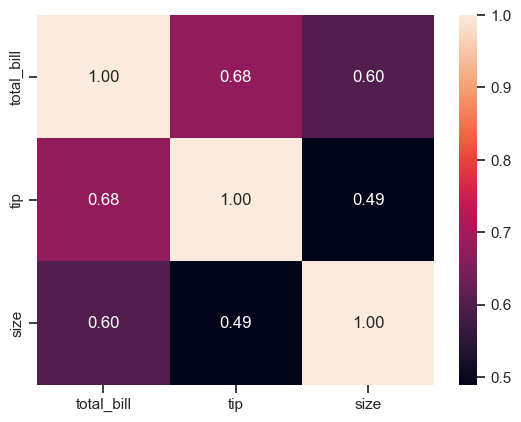

In [32]:
# tips데이터셋 - 상관계수 & 히트맵
# 1. 상관계수
# 2. 히트맵
tips_corr_mat = tips_df.corr(numeric_only=True)
sns.heatmap(tips_corr_mat, annot=True, fmt='.2f')
plt.show()

In [33]:
# 차량연비 데이터셋
mpg_df = sns.load_dataset("mpg")
mpg_df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


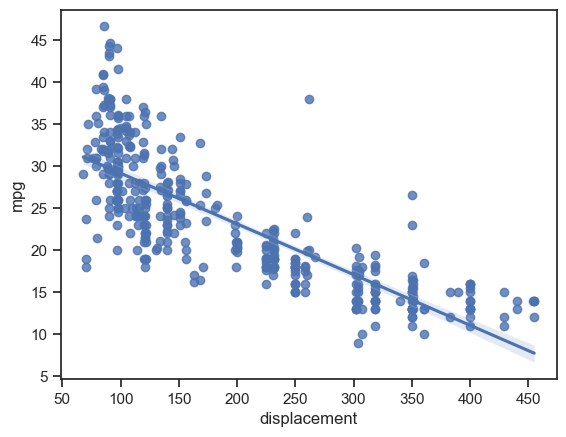

In [34]:
# 음의 상관관계
# 배기량과 연비
sns.regplot(data=mpg_df, x='displacement', y='mpg')
plt.show()

In [35]:
# TODO - Regplot
# mpg_df에서 horsepower와 mpg 관계를 regplot으로 그려보세요.
# 음의 상관인지 양의 상관인지 한 줄로 적어보세요.

## 9. FacetGrid
- 범주형 변수로 데이터를 나눈 뒤, 각 하위 집합의 패턴을 별도 패널로 비교할 수 있다.
- FacetGrid col/row 그룹핑 (범주형)
- map함수 하위컬럼 지정

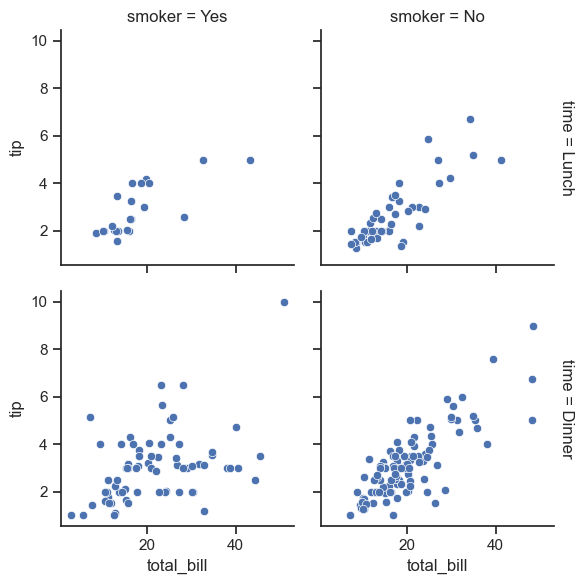

In [36]:
# 시간대(점심/저녁), 흡연여부에 따라 grid를 작성
facet_grid = sns.FacetGrid(
    data=tips_df, row='time', col='smoker',
    margin_titles=True)
facet_grid.map(sns.scatterplot, 'total_bill', 'tip')
plt.show()

In [37]:
# TODO - FacetGrid
# titanic_df를 사용하여 성별별로 나이(Age)와 요금(Fare)의 산포도를 그려보세요.
# 조건
# 1) FacetGrid를 이용해 Sex별로 컬럼(col)을 나누기
# 2) map() 함수와 sns.scatterplot을 사용하여 나이와 요금의 관계를 시각화하기

## 정리
- Seaborn은 Matplotlib보다 적은 코드로 통계적 시각화를 만들기 쉽다.
- countplot과 barplot의 차이를 설명할 수 있어야 한다.
- boxplot과 violinplot의 차이를 설명할 수 있어야 한다.
- heatmap, pairplot, regplot, FacetGrid는 탐색적 데이터 분석에서 자주 쓰인다.